# Sampling datasets for eval

In [2]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [3]:
N_NUMBER = 105
SEED = 45

In [4]:
path_name = '/Users/sabijn/Documents/PhD/Datasets/chisor_dataset_all/ChiSCor_CoNLL_paper/csv/ChiSCor_master_df_password/ChiSCor_master_df.csv'
df_chiscor = pd.read_csv(path_name, index_col=0)

In [5]:
sftw = load_dataset('Sabijn/StoriesfortheWin')

## Sample ChiSCor

In [6]:
n_groups = df_chiscor["agegroup_str"].nunique()
samples_per_group = N_NUMBER // n_groups
remainder = N_NUMBER % n_groups

# Sample equally per group
sampled_chiscor = (
    df_chiscor.groupby("agegroup_str")
    .apply(lambda x: x.sample(n=min(samples_per_group, len(x)), random_state=SEED))
    .reset_index(drop=True)
)

# Top up with random rows not yet sampled
if remainder > 0:
    remaining = df_chiscor[~df_chiscor.index.isin(sampled_chiscor.index)]
    extra = remaining.sample(n=remainder, random_state=42)
    sampled_chiscor = pd.concat([sampled_chiscor, extra]).reset_index(drop=True)

/var/folders/56/dn1qm9sj61b44vvdmb8pnkp80000gn/T/ipykernel_68135/1712543528.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(samples_per_group, len(x)), random_state=SEED))


In [7]:
print(sampled_chiscor["agegroup_str"].value_counts())
print(len(sampled_chiscor))

agegroup_str
10-11    15
11-12    15
4-6      15
6-7      15
7-8      15
8-9      15
9-10     15
Name: count, dtype: int64
105


In [8]:
sampled_chiscor["story_length"] = sampled_chiscor["story_raw"].str.split().str.len()

Text(0.5, 1.0, 'Story length')

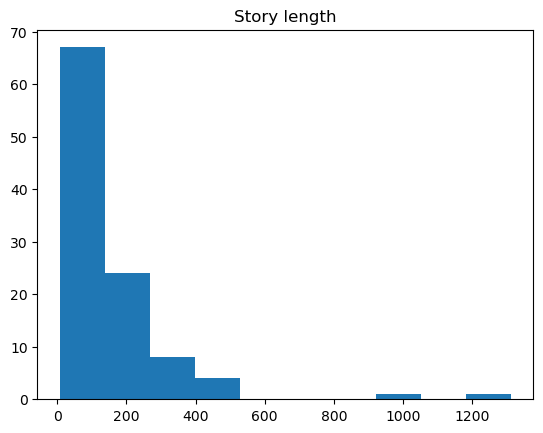

In [9]:
plt.hist(sampled_chiscor['story_length'])
plt.title('Story length')

## Sample SFTW

In [10]:
sampled_sftw = sftw["train"].shuffle(seed=SEED).select(range(N_NUMBER))
len(sampled_sftw)

105

In [11]:
sampled_sftw.column_names

['index', 'story']

## Merge and create samples csv

In [ ]:
coworker_n = 50

# Extract just the story columns, rename, and add source column
hf_stories = pd.DataFrame(sampled_sftw["story"], columns=["story"])
hf_stories["source"] = "sftw"

pd_stories = pd.DataFrame(sampled_chiscor["story_raw"]).rename(columns={"story_raw": "story"})
pd_stories["source"] = "chiscor"

# Merge (concatenate) the two story columns
merged = pd.concat([hf_stories, pd_stories], ignore_index=True)
merged["id"] = range(len(merged))

# Write samples to CSV
merged.to_csv("samples.csv", index=False)
merged.iloc[:coworker_n].to_csv("samples_gijs.csv", index=False)
merged.iloc[coworker_n:].to_csv("samples_me.csv", index=False)

In [2]:
samples_me = pd.read_csv("samples_me.csv")

coworker2_n = 50
samples_me.iloc[:coworker2_n].to_csv("samples_suzan.csv", index=False)
samples_me.iloc[coworker2_n:].to_csv("samples_me_aftersuzan.csv", index=False)

In [13]:
# Merging afterwards (merging questions)
# q1 = pd.read_csv("questions_part1.csv")
# q2 = pd.read_csv("questions_part2.csv")
# merged_questions = pd.concat([q1, q2], ignore_index=True).sort_values("id")

In [3]:
df = pd.concat([
    pd.read_csv('questions_gijs.csv'),
    pd.read_csv('questions_suzan.csv'),
    pd.read_csv('questions_sabijn.csv')
], ignore_index=True)

df.to_csv('questions_all.csv', index=False)

## Select final eval set

Logboek:
- 2, ChiSCor, over 600 words
- 1, ChiSCor, anonymized (#142)
- 2, ChiSCor, too short (#144), (#161)
- random sampled 100 from 105 from StoriesfortheWin

In [9]:
import pandas as pd
import json

df = pd.read_csv("questions_all.csv")
df['story_length'] = df["story"].str.split().str.len()

In [ ]:
df = df[df['story_length'] < 600] # too long stories
df = df[df['id'] != 142] # anonymized

In [25]:
df = df[df['id'] != 144] # anonymized
df = df[df['id'] != 161] # anonymized

In [30]:
mask = df['source'] == 'sftw'

df = pd.concat([
    df[mask].sample(n=min(100, mask.sum())),
    df[~mask]
])

In [31]:
df['source'].value_counts()

source
sftw       100
chiscor    100
Name: count, dtype: int64

In [33]:
df.to_csv('questions_cleaned_and_sampled.csv', index=False)

In [37]:
len(df)

200

## Convert pd to js for qualtrics

In [22]:
import pandas as pd
import json
import re

def capitalize_sentences(text):
    return re.sub(r'((?:^|(?<=[.!?])\s+))([a-z])', lambda m: m.group(1) + m.group(2).upper(), text)

df = pd.read_csv("questions_cleaned_and_sampled.csv")

# Capitalize first letter of story for chiscor rows only
mask = df["source"] == "chiscor"
df.loc[mask, "story"] = df.loc[mask, "story"].apply(capitalize_sentences)

# Now drop story_length
df = df.drop(columns=["story_length"])

stories = []
for _, row in df.iterrows():
    story = {
        "id": row["id"],
        "source": row["source"],
        "text": row["story"],
        "question": row["question"],
        "options": [row["answer_a"], row["answer_b"], row["answer_c"]],
        "correct": row["gold_label"]
    }
    stories.append(story)

js_output = "var stories = " + json.dumps(stories, indent=2, ensure_ascii=False) + ";"

with open("stories_js.txt", "w", encoding="utf-8") as f:
    f.write(js_output)

print("Done! Paste the contents of stories_js.txt into your Qualtrics JS.")

Done! Paste the contents of stories_js.txt into your Qualtrics JS.


## Merge two result files

In [ ]:
import pandas as pd

first_result = pd.read_csv('llm_judge_results.csv')
second_result = pd.read_csv('llm_judge_results_aya_gemma.csv')

In [11]:
first_result = first_result.dropna()
first_result = first_result[first_result['judge'] != 'llama3.1:8b']
first_result

,id,judge,grammaticality,coherence,originality,creativity,complexity,likeability,humanlikeness
3,34,qwen2.5:14b,4.0,3.0,3.0,4.0,3.0,4.0,2.0
4,34,mistral-small3.2,5.0,4.0,4.0,4.0,3.0,4.0,3.0
6,95,qwen2.5:14b,4.0,3.0,3.0,5.0,2.0,4.0,3.0
7,95,mistral-small3.2,4.0,3.0,4.0,4.0,3.0,3.0,4.0
9,92,qwen2.5:14b,4.0,3.0,3.0,4.0,2.0,4.0,4.0
...,...,...,...,...,...,...,...,...,...
595,207,mistral-small3.2,3.0,3.0,4.0,4.0,3.0,3.0,4.0
597,208,qwen2.5:14b,3.0,2.0,4.0,5.0,3.0,2.0,4.0
598,208,mistral-small3.2,4.0,3.0,4.0,4.0,3.0,3.0,4.0
600,209,qwen2.5:14b,3.0,2.0,4.0,4.0,2.0,3.0,5.0


In [18]:
second_result = second_result.dropna()

In [19]:
all_results = pd.concat([first_result, second_result])
all_results['judge'].value_counts()

judge
aya-expanse:32b     199
gemma3:12b          199
qwen2.5:14b         197
mistral-small3.2    196
Name: count, dtype: int64

In [20]:
all_results.to_csv('llm_judge_results_concat.csv', index=False)

## Convert stories to csv for google sheets

In [15]:
import pandas as pd
import numpy as np
import json

df = pd.read_csv("questions_cleaned_and_sampled.csv")

n_respondents = 60
ratings_per_story = 3
stories_per_respondent = 10
stories_per_source = 5

# Split by source
source_a = df[df["source"] == "chiscor"]["id"].tolist()
source_b = df[df["source"] == "sftw"]["id"].tolist()

print(f"Source A stories: {len(source_a)}")
print(f"Source B stories: {len(source_b)}")

def make_assignments(source, n_respondents, stories_per_respondent):
    """
    Creates assignments such that:
    - Each story appears exactly ratings_per_story times
    - No respondent gets the same story twice
    - Assignments are fully randomized
    """
    n_stories = len(source)
    
    # Create a matrix of shape (n_stories, ratings_per_story)
    # Each row is a story, each column is one of its 3 appearances
    # We need to assign each story to exactly 3 respondents
    
    # Create pool: each story repeated ratings_per_story times
    pool = source * ratings_per_story
    
    max_attempts = 1000
    for attempt in range(max_attempts):
        np.random.shuffle(pool)
        
        # Split into respondent chunks
        assignments = [
            pool[i*stories_per_respondent:(i+1)*stories_per_respondent]
            for i in range(n_respondents)
        ]
        
        # Check no duplicates within any assignment
        valid = all(
            len(a) == len(set(a))
            for a in assignments
        )
        
        if valid:
            print(f"Valid assignment found after {attempt+1} attempts")
            return assignments
    
    raise ValueError("Could not find valid assignment after 1000 attempts — check your story counts!")

# Generate assignments for each source
print("Generating source A assignments...")
assignments_a = make_assignments(source_a, n_respondents, stories_per_source)

print("Generating source B assignments...")
assignments_b = make_assignments(source_b, n_respondents, stories_per_source)

# Combine and shuffle order within each respondent's assignment
assignments = []
for i in range(n_respondents):
    combined = list(assignments_a[i]) + list(assignments_b[i])
    
    # Final check for duplicates
    assert len(combined) == len(set(combined)), f"Duplicate found in assignment {i}!"
    
    np.random.shuffle(combined)
    assignments.append([int(x) for x in combined])

# Verify coverage
from collections import Counter
all_stories = [story for assignment in assignments for story in assignment]
coverage = Counter(all_stories)
print(f"\nCoverage stats:")
print(f"Min ratings per story: {min(coverage.values())}")
print(f"Max ratings per story: {max(coverage.values())}")
print(f"Stories with exactly 3 ratings: {sum(1 for v in coverage.values() if v == 3)}")

# Save as CSV for pasting into Google Sheets
rows = []
for i, assignment in enumerate(assignments):
    rows.append({
        "assignment_id": i,
        "stories": json.dumps(assignment)
    })

pd.DataFrame(rows).to_csv("assignments_sheets.csv", index=False)
print(f"\nGenerated {len(assignments)} assignments — saved to assignments_sheets.csv")

Source A stories: 100
Source B stories: 100
Generating source A assignments...
Valid assignment found after 16 attempts
Generating source B assignments...
Valid assignment found after 84 attempts

Coverage stats:
Min ratings per story: 3
Max ratings per story: 3
Stories with exactly 3 ratings: 200

Generated 60 assignments — saved to assignments_sheets.csv


In [21]:
string_ids = []
for r in rows:
    string_ids.append(r['stories'])
print(len(set(string_ids)))


60
